# 

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df =  pd.read_excel(r"D:\Datases_CD\7mo\Mineria_de_datos\Practicas\P9\nyc_benchmarking_disclosure_2017_consumption_data.xlsx", sheet_name='Information and Metrics')
df.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2 (self-reported),...,Annual Maximum Demand (kW),Annual Maximum Demand (MM/YYYY),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Water Use (All Water Sources) (kgal),Water Use Intensity (All Water Sources) (gal/ft²),Water Required?,Generation Date,DOF Benchmarking Submission Status
0,1,4593574,The Argonaut Building,NaN,NaN,1.010288e+09,1010287502,1024898,224 West 57th St,NaN,...,NaN,NaT,732.4,76.3,656.1,3635.5,21.46,Not found,2018-02-14,Not found
1,3,2967701,Cathedral Preparatory Seminary,NaN,NaN,4.018720e+09,4-01872-0007,4046340,56-25 92nd Street,NaN,...,NaN,NaT,164.5,109.9,54.6,102.9,1.09,Not found,2018-02-14,Not found
2,4,4898531,The Nomad Hotel,NaN,NaN,1.008290e+09,1-00829-0050,1080710,1170 Broadway,NaN,...,NaN,NaT,1150.2,438.0,712.3,10762.6,86.10,Not found,2018-02-14,Not found
3,5,2917939,10 West 27 Street Corp,NaN,NaN,1.008280e+09,1-00828-0053,1015657,1155 Broadway,NaN,...,NaN,NaT,273.4,98.2,175.3,790.1,15.80,Not found,2018-02-14,Not found
4,6,3878205,Westbury Realty,NaN,NaN,1.000650e+09,1-00065-0024,1001105,24 John Street,NaN,...,NaN,NaT,90.7,0.0,90.7,143.0,2.86,Not found,2018-02-14,Not found


In [10]:
print("Dimensiones del DataFrame:", df.shape)
print("\nPrimeras columnas:")
print(df.head(3))

Dimensiones del DataFrame: (34355, 60)

Primeras columnas:
   Order  Property Id                   Property Name Parent Property Id  \
0      1      4593574           The Argonaut Building                NaN   
1      3      2967701  Cathedral Preparatory Seminary                NaN   
2      4      4898531                 The Nomad Hotel                NaN   

  Parent Property Name  BBL - 10 digits  \
0                  NaN     1.010288e+09   
1                  NaN     4.018720e+09   
2                  NaN     1.008290e+09   

  NYC Borough, Block and Lot (BBL) self-reported  \
0                                     1010287502   
1                                   4-01872-0007   
2                                   1-00829-0050   

  NYC Building Identification Number (BIN) Address 1 (self-reported)  \
0                                  1024898          224 West 57th St   
1                                  4046340         56-25 92nd Street   
2                                  108

In [11]:
na_counts = df.isna().sum()
na_percent = (na_counts / len(df)) * 100
na_summary = pd.DataFrame({
    'Valores_NaN': na_counts,
    '%_NaN': na_percent
}).sort_values(by='Valores_NaN', ascending=False)

print("\nResumen de valores faltantes:")
print(na_summary.head(15))


Resumen de valores faltantes:
                                                    Valores_NaN      %_NaN
Propane Use (kBtu)                                        34354  99.997089
District Hot Water Use (kBtu)                             34347  99.976714
District Chilled Water Use (kBtu)                         34325  99.912676
Fuel Oil #1 Use (kBtu)                                    34319  99.895212
Diesel #2 Use (kBtu)                                      34285  99.796245
Address 2 (self-reported)                                 33928  98.757095
Fuel Oil #5 & 6 Use (kBtu)                                33871  98.591180
District Steam Use (kBtu)                                 32787  95.435890
Parent Property Name                                      32632  94.984718
Parent Property Id                                        32632  94.984718
Fuel Oil #4 Use (kBtu)                                    31977  93.078155
Annual Maximum Demand (MM/YYYY)                           31972  93.0

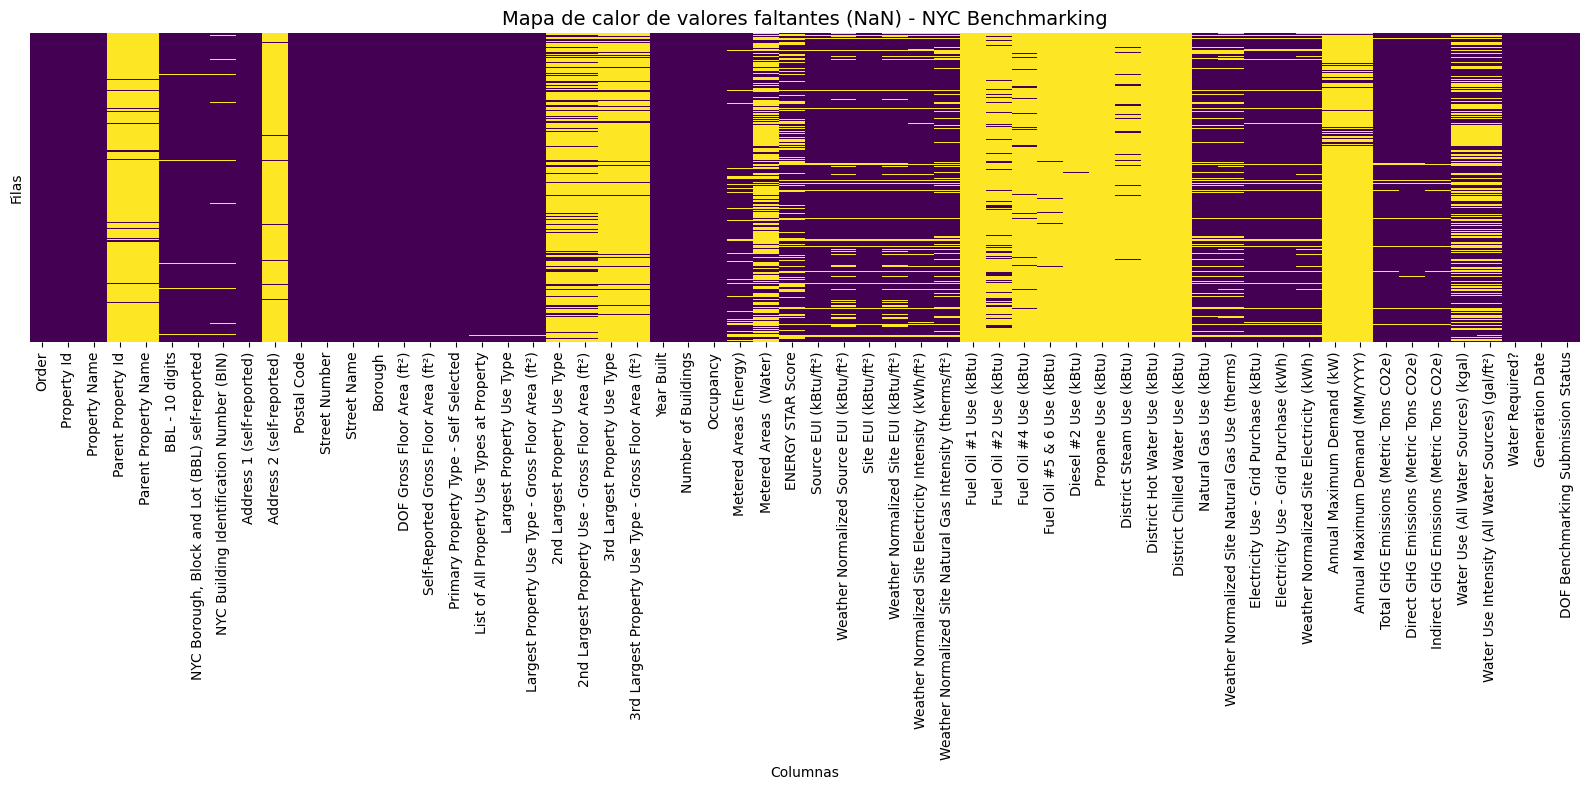

In [12]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.isnull(), 
            cbar=False, 
            cmap="viridis", 
            yticklabels=False)

plt.title("Mapa de calor de valores faltantes (NaN) - NYC Benchmarking", fontsize=14)
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

Ella borro todos aquellos donde no tuvieran mas del 50% de los datos , lo cual esta mal , pues puedes borrar datos que te pueden servir. Solo los borro por que si y no entendo el uso de los datos o entedimiento del problema 

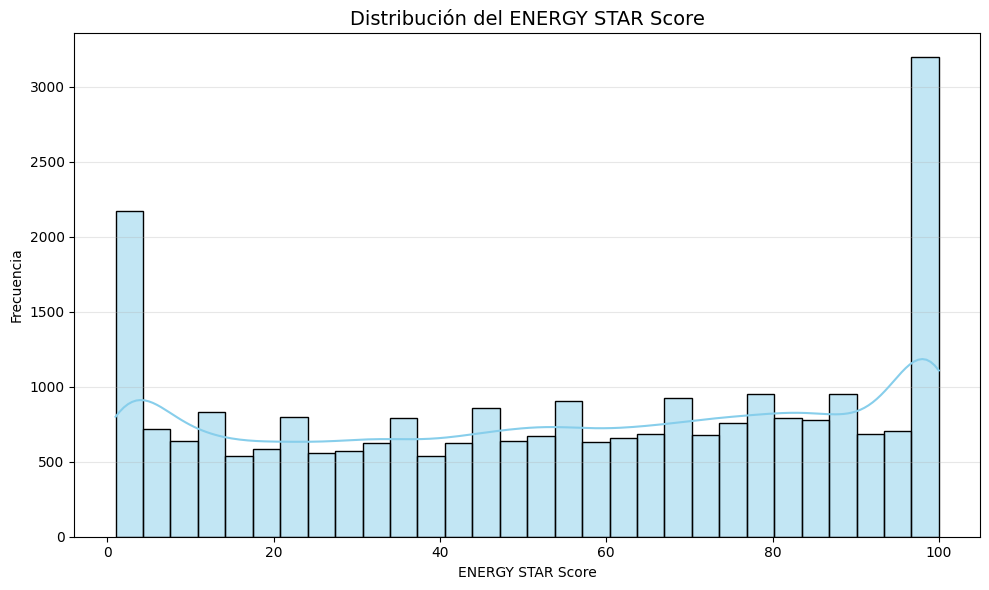

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ENERGY STAR Score'].dropna(), 
             bins=30, 
             kde=True, 
             color='skyblue', 
             edgecolor='black')

plt.title("Distribución del ENERGY STAR Score", fontsize=14)
plt.xlabel("ENERGY STAR Score")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

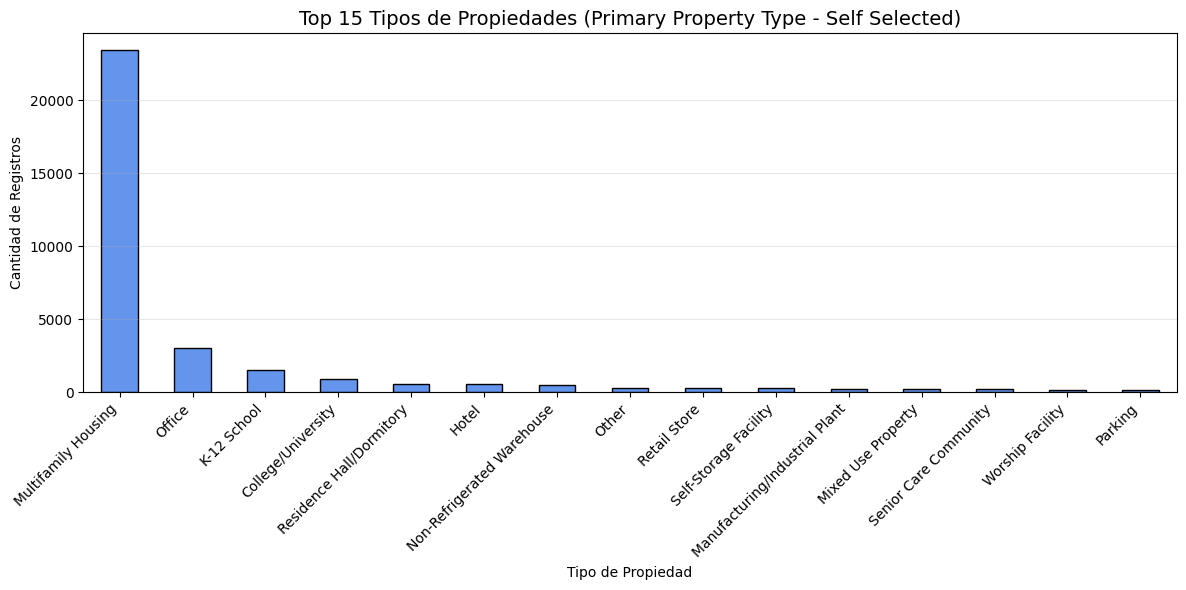

In [14]:
plt.figure(figsize=(12, 6))
df['Primary Property Type - Self Selected'].value_counts().head(15).plot(
    kind='bar',
    color='cornflowerblue',
    edgecolor='black'
)

plt.title("Top 15 Tipos de Propiedades (Primary Property Type - Self Selected)", fontsize=14)
plt.xlabel("Tipo de Propiedad")
plt.ylabel("Cantidad de Registros")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Comparado con lo ella realizo , aparentemente en la limpieza borro muchas categorias(ya que a ella solo le aprecen 4). Lo cual puede sesagar el modelo o incluso si quieres predecir un tipo de inmueble ya no vas a poder. 

Tambien ella menciona que las variables estan correlacionadas en base a su visualizacion de las distribuciones , lo cual esta mal!!! No puedes asegurar una correlacion asi debes de hacer purebas y ese tipo de grafico no me dicen , si acaso me diran que si son separabales.

C:\Users\ENRIQUE\AppData\Local\Temp\ipykernel_18876\3949174332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


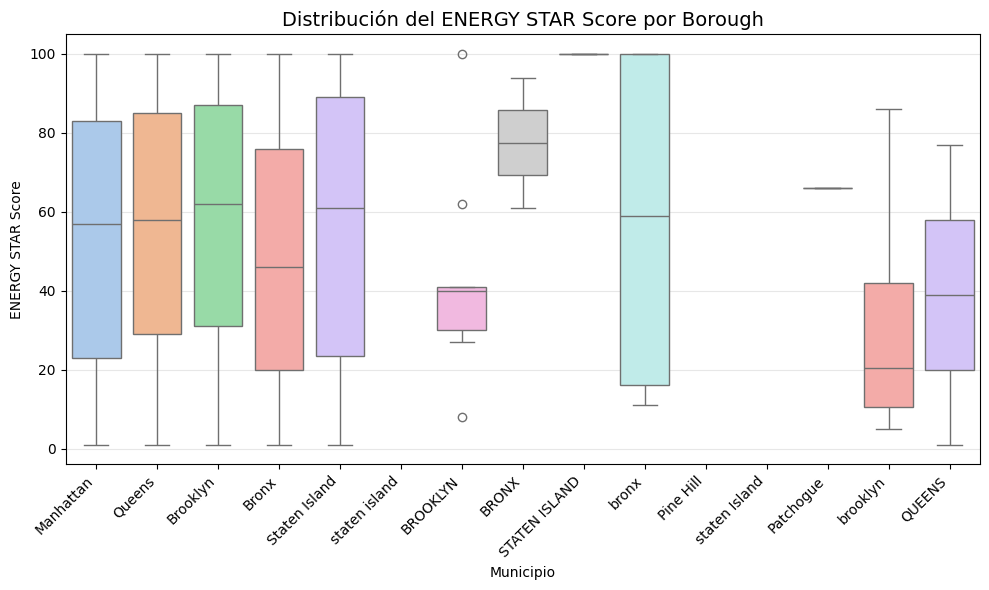

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, 
            x='Borough', 
            y='ENERGY STAR Score', 
            palette='pastel')

plt.title("Distribución del ENERGY STAR Score por Borough", fontsize=14)
plt.xlabel("Municipio")
plt.ylabel("ENERGY STAR Score")
plt.xticks(rotation=45, ha='right')  
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


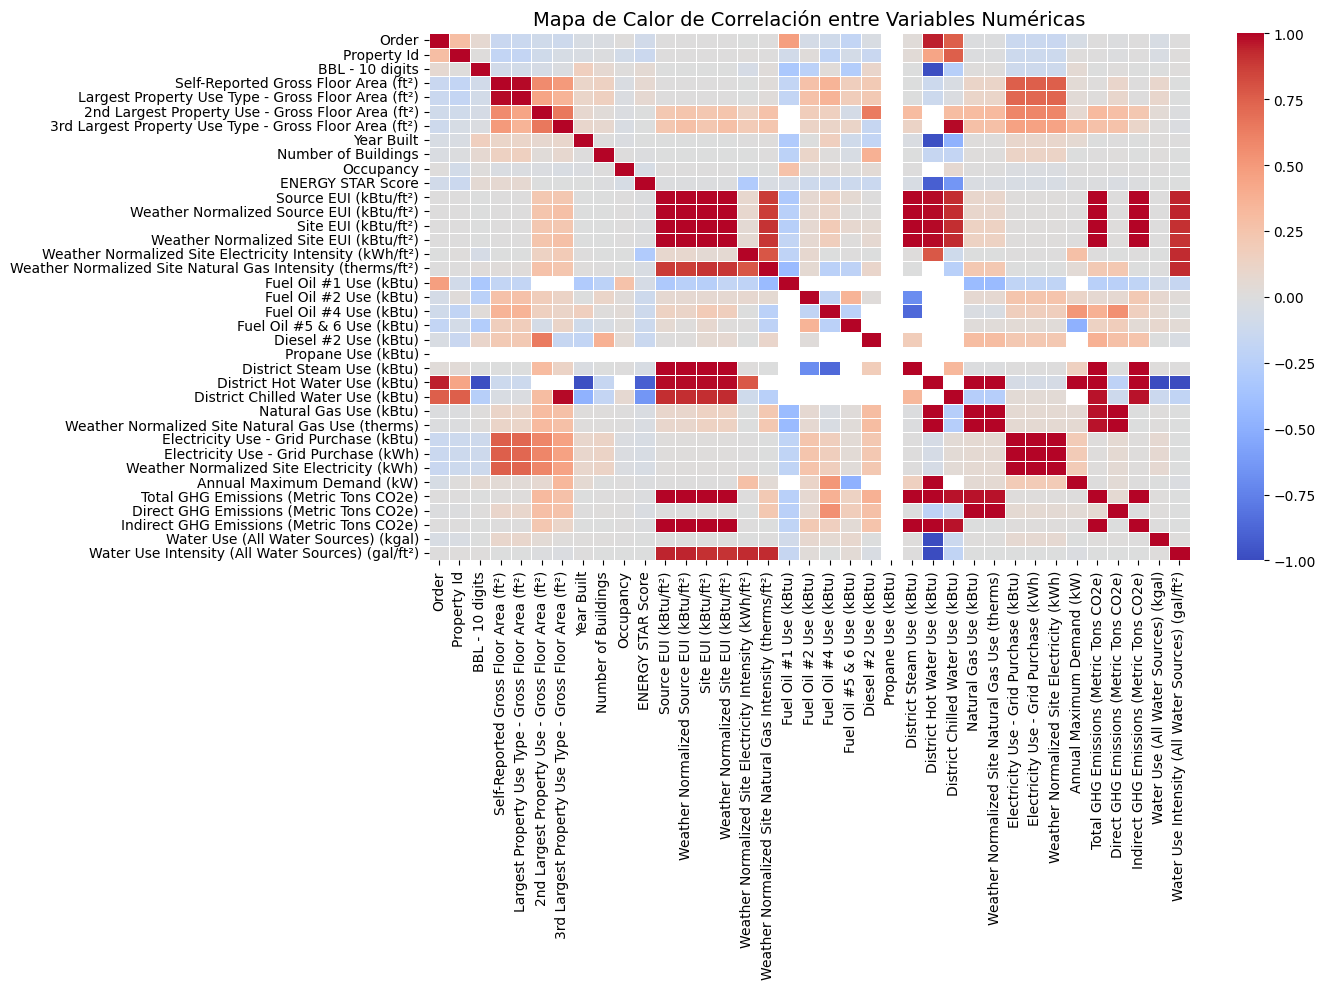

In [ ]:
# Seleccionar solo las columnas numéricas
num_df = df.select_dtypes(include=['number'])
corr_matrix = num_df.corr()

# Visualizar con un heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=False,  
            linewidths=0.5)

plt.title("Mapa de Calor de Correlación entre Variables Numéricas", fontsize=14)
plt.tight_layout()
plt.show()